In [2]:
!pip install -qU langgraph langchain langchain-core ddgs pygraphviz boto3 langchain-aws

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import DuckDuckGoSearchRun

In [4]:
tool = DuckDuckGoSearchRun()

In [5]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [6]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_model(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [8]:
import boto3
import json

bedrock = boto3.client('bedrock-runtime', region_name='us-east-1')

request_body = {
    'messages': [
        {
            'role': 'user',
            'content': [{'text': 'What is AWS bedrock AgentCore?'}]
        }
    ],
    'inferenceConfig': {
        'maxTokens': 512,
        'temperature': 0.7
    }
}

response = bedrock.invoke_model(
    modelId='us.amazon.nova-2-lite-v1:0',
    body=json.dumps(request_body)
)

response_body = json.loads(response['body'].read())
content_list = response_body["output"]["message"]["content"]
# Extract the first text block
text_block = next((item for item in content_list if "text" in item), None)
if text_block is not None:
    print(text_block["text"])

### **AWS Bedrock AgentCore: Overview**

**AWS Bedrock AgentCore** is a foundational component within the **Amazon Bedrock** service that enables the creation, deployment, and management of **AI-powered agents**. These agents are designed to interact with users (via text, voice, or other inputs) and perform tasks autonomously by leveraging large language models (LLMs) and integrating with various AWS services and external APIs.

---

## **What is an Agent in AWS Bedrock?**

In the context of AWS Bedrock, an **agent** is an AI service that can:
- Understand natural language input from users.
- Determine the appropriate action to take (e.g., calling an API, querying a database, or executing a Lambda function).
- Maintain context and conversation history.
- Provide coherent and relevant responses.

Agents are particularly useful for building **customer service chatbots**, **automated support systems**, **data analysis tools**, and **workflow automation** systems.

---

## **What is AgentC

In [20]:
from langchain_aws import ChatBedrock

# Replace the OpenAI model with AWS Nova Lite
model = ChatBedrock(
    
    model_id="us.amazon.nova-2-lite-v1:0",  
   # model_id="us.anthropic.claude-3-5-haiku-20241022-v1:0",
    model_kwargs={
        "temperature": 0,
        "top_p": 1,
        "max_tokens": 1000,
    }
)

In [21]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

test_agent = Agent(model, [tool], system=prompt)


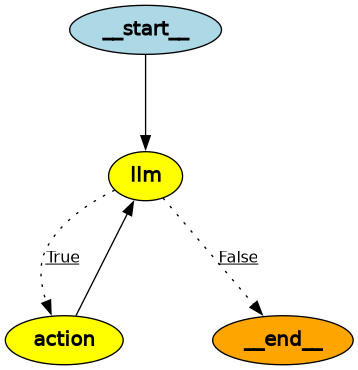

In [18]:
from IPython.display import Image

Image(test_agent.graph.get_graph().draw_png())

In [22]:
messages = [HumanMessage(content="What is the latest news in MIT?")]
result = test_agent.graph.invoke({"messages": messages})

Calling: {'name': 'duckduckgo_search', 'args': {'query': 'MIT latest news'}, 'id': 'tooluse_scxyaDW4RIWtH1j2EXY6xg', 'type': 'tool_call'}
Back to the model!


In [23]:
result

{'messages': [HumanMessage(content='What is the latest news in MIT?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'tool_use', 'name': 'duckduckgo_search', 'input': {'query': 'MIT latest news'}, 'id': 'tooluse_scxyaDW4RIWtH1j2EXY6xg'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '1bc4aa4f-602c-4618-b389-a7ffd5d4084e', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Mon, 02 Feb 2026 14:25:09 GMT', 'content-type': 'application/json', 'content-length': '316', 'connection': 'keep-alive', 'x-amzn-requestid': '1bc4aa4f-602c-4618-b389-a7ffd5d4084e'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [486]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.amazon.nova-2-lite-v1:0'}, id='lc_run--019c1ebe-37ab-71e1-86f1-0412d86431ad-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'MIT latest news'}, 'id': 'tooluse_scxyaDW4RIWtH1j2EXY6xg', 'type': 'tool_call'}], invalid_tool_calls=[], usage_

In [24]:
result['messages'][-1].content

"Here are some of the latest news headlines related to MIT:\n\n1. **MIT Technology Review 2026 Breakthrough Technologies List**: MIT Technology Review has announced its 2026 list of 10 Breakthrough Technologies, highlighting innovations in AI, biotech, space, and energy that are expected to shape the future.\n\n2. **MIT Closes DEI Office**: The Massachusetts Institute of Technology recently closed its Diversity, Equity, and Inclusion (DEI) office following an 18-month assessment. This decision comes amid ongoing disputes with other institutions, such as Harvard, regarding DEI initiatives under Trump's administration.\n\nThese updates reflect both the cutting-edge research and evolving institutional policies at MIT. Let me know if you'd like more details on either story!"